### Assess Recovery

We fit a bunch of injected events, or at least those that passed our event and anomaly detection pipeline. Let's assess how well we did in 1) detection and 2) classification. 

#### Detection Recovery

In [1]:
# system imports
import os
import time
import sys
import glob
from tqdm import tqdm
#from pathlib import Path

# data access imports
import pandas as pd
from astropy.coordinates import SkyCoord
import astropy.units as u

# display imports
from IPython.display import HTML

# multiprocessing imports
import multiprocessing as mp
from multiprocessing.pool import ThreadPool

# data challenge imports
#import MulensModel
import emcee
#from pyLIMA.pyLIMASS import SourceLensProbabilities
import RTModel

# data analysis/visualization imports
import numpy as np
import matplotlib.pyplot as plt

#### IMPORTANT: Who are you? 

In [2]:
event_data_me = 'event_data_chris/' # please change 'chris' to your name, otherwise you will overwrite my work

#### Mise en place

In [3]:
TIER = "Beginner" # change to Experienced or ML if you want to not be a baby
root_dir = '/home/mldc-ipacpeople-admin/teams/mldc-ipacpeople/'
events_dir = root_dir + event_data_me

In [4]:
def read_nature_txt(filename, n_chisquares):
    """
    Read Nature.txt if it's not empty and grab the top n_chisquares models. 
    """
    found = False
    n = 0
    chisqs = []
    model_files = []
    with open(filename, "r") as file:
        for line in file:
            # don't do anything until the chisquare line, which is where FinalModels are listed
            if 'chisquare' in line:
                found = True 
                continue # skip to next line, our search for the chisquare line is done
            
            # only then do we start processing lines
            if found == True:
                #print(line.strip())  # strip() removes trailing newlines

                # grab best N chisquares
                if n < n_chisquares:
                    chisq = line.split()[0]
                    model_file = line.split()[1]
                    chisqs.append(chisq)
                    model_files.append(model_file)
                else: 
                    continue
    
                n += 1
    file.close() 

    return chisqs, model_files

What fraction of favored models are planetary events? Of these, what are "contested" (either LS or BS is also among the favored models for that event)? 

In [5]:
if TIER == "Beginner":
    assess_range = np.arange(1,189)
elif TIER == "Experienced":
    assess_range = np.arange(189,2289)

n_chisquares = 1 # how many of the best chisquares to take
count_ls_list = []
count_bs_list = []
count_ps_list = []
for i in tqdm(assess_range[:98]): # need to re-run all events, but especially 1-38
    if int(i) < 1000:
        event_dir = events_dir + 'event_000' + "{:03d}/".format(i)
    elif 1000 <= int(i) < 10000:
        event_dir = events_dir + 'event_00' + "{:04d}/".format(i)
    event_final_models = glob.glob(event_dir+'FinalModels/*')

    # if there are no FinalModels (ie., if either there was no detection or there was no 
    if len(event_final_models)==0:
        count_ps_list.append(0)
        count_ls_list.append(0)
        count_bs_list.append(0)
        continue
    else:
        chisqs, model_filenames = read_nature_txt(event_dir+'Nature.txt', n_chisquares=len(event_final_models))

    # read N best model_filenames to get inferred parameters
    count_ls = 0
    count_bs = 0
    count_ps = 0
    #for j in range(n_chisquares):
    for j in range(len(event_final_models)): 
        chisq_temp = chisqs[j]
        model_filename_temp = model_filenames[j]
        # 1) how many events have LS, LX, or LO in FinalModels/?
        if (model_filename_temp[:2] == 'LS') or (model_filename_temp[:2] == 'LX') or (model_filename_temp[:2] == 'LO'):
            count_ls += 1
        if (model_filename_temp[:2] == 'BS') or (model_filename_temp[:2] == 'BO'):
            count_bs += 1
        if (model_filename_temp[:2] == 'PS') or (model_filename_temp[:2] == 'PX'):
            count_ps += 1

    count_ls_list.append(count_ls)
    count_bs_list.append(count_bs)
    count_ps_list.append(count_ps)
            
final_models_df = pd.DataFrame({'event': np.arange(1,99), 'PS': count_ps_list, 'LS': count_ls_list, 'BS': count_bs_list})       
        
        

100%|██████████| 98/98 [00:08<00:00, 11.42it/s]


In [6]:
final_models_df

,event,PS,LS,BS
0,1,0,3,0
1,2,0,4,1
2,3,0,1,0
3,4,1,0,0
4,5,0,10,0
...,...,...,...,...
93,94,0,1,0
94,95,0,2,0
95,96,0,1,0
96,97,1,0,0


In [8]:
# how many of each archetype?
print(final_models_df)
final_models_none = final_models_df.loc[(final_models_df['PS']==0)&(final_models_df['LS']==0)&(final_models_df['BS']==0)]
final_models_ps = final_models_df.loc[final_models_df['PS']>0]
final_models_ls = final_models_df.loc[final_models_df['LS']>0]
final_models_bs = final_models_df.loc[final_models_df['BS']>0]

print("fraction w/o good model: ", len(final_models_none)/len(final_models_df))
print("fraction with PS: ", len(final_models_ps)/len(final_models_df))
print("fraction with LS: ", len(final_models_ls)/len(final_models_df))
print("fraction with BS: ", len(final_models_bs)/len(final_models_df))

final_models_ls_only = final_models_ls.loc[(final_models_ls['PS']==0)&(final_models_ls['BS']==0)]
print("fraction with LS, unambiguously: ", len(final_models_ls_only)/len(final_models_df))

#final_models_lo = 


    event  PS  LS  BS
0       1   0   3   0
1       2   0   4   1
2       3   0   1   0
3       4   1   0   0
4       5   0  10   0
..    ...  ..  ..  ..
93     94   0   1   0
94     95   0   2   0
95     96   0   1   0
96     97   1   0   0
97     98   0   0   0

[98 rows x 4 columns]
fraction w/o good model:  0.3673469387755102
fraction with PS:  0.12244897959183673
fraction with LS:  0.4897959183673469
fraction with BS:  0.15306122448979592
fraction with LS, unambiguously:  0.35714285714285715


In [10]:
if TIER == "Beginner":
    assess_range = np.arange(1,189)
elif TIER == "Experienced":
    assess_range = np.arange(189,2289)
n_chisquares = 1 # how many of the best chisquares to take
s_list, q_list, u0_list, alpha_list, rho_list, tE_list, t0_list = [], [], [], [], [], [], []
s_err_list, q_err_list, u0_err_list, alpha_err_list, rho_err_list, tE_err_list, t0_err_list = [], [], [], [], [], [], []
event_list, chisq_list = [], []
back_flux1_list, source_flux1_list, back_flux2_list, source_flux2_list, back_flux3_list, source_flux3_list = [], [], [], [], [], []

for i in tqdm(assess_range[:98]):
    if int(i) < 1000:
        event_dir = events_dir + 'event_000' + "{:03d}/".format(i)
    elif 1000 <= int(i) < 10000:
        event_dir = events_dir + 'event_00' + "{:04d}/".format(i)
    event_final_models = glob.glob(event_dir+'FinalModels/*')

    # if there are no FinalModels (ie., if either there was no detection or there wasn't a strong enough detection) 
    if len(event_final_models)==0:
        continue
    else:
        chisqs, model_filenames = read_nature_txt(event_dir+'Nature.txt', n_chisquares)

    # read N best model_filenames to get inferred parameters
    for j in range(n_chisquares):
        chisq_temp = chisqs[j]
        model_filename_temp = model_filenames[j]        
        
        with open(event_dir + 'FinalModels/' + model_filename_temp, "r") as model_file:
            # look at only the first two lines. The rest is the covariance matrix, which we're not interested in for now.
            lines = model_file.readlines()
            line1 = lines[0]
            line2 = lines[1]
    
            # FinalModels/ files have variable columns depending on the model archetype. Account for this.
            if model_filename_temp[:2] == 'LS':
                s,q,u0,alpha,rho,tE,t0,back_flux,source_flux,anomaly_t0,anomaly_y1,anomaly_y2,anomaly_Delta_chisq,chisq = line1.split()
                s_err,q_err,u0_err,alpha_err,rho_err,tE_err,t0_err,anomaly_t0_err,anomaly_y1_err,anomaly_y2_err,anomaly_Delta_chisq_err,unk5_err,unk6_err = line2.split()
                event_list.append(int(i))
                chisq_list.append(float(chisq))
                s_list.append(float(s))
                q_list.append(float(q))
                u0_list.append(float(u0))
                alpha_list.append(float(alpha))
                rho_list.append(float(rho))
                tE_list.append(float(tE))
                t0_list.append(float(t0))

                s_err_list.append(float(s_err))
                q_err_list.append(float(q_err))
                alpha_err_list.append(float(alpha_err))
            #elif model_file_name_temp[:2] == '
        
        #model_file.close() 

100%|██████████| 98/98 [00:04<00:00, 21.80it/s]


In [11]:
best_models_ls = pd.DataFrame({'event':event_list,'chisq':chisq_list,'s':s_list,'q':q_list,'u0':u0_list,'alpha':alpha_list,'rho':rho_list,
                        'tE':tE_list,'t0':t0_list,'s_err':s_err_list,'q_err':q_err_list,'alpha_err':alpha_err_list})

In [12]:
best_models_ls

,event,chisq,s,q,u0,alpha,rho,tE,t0,s_err,q_err,alpha_err
0,1,7193.590293,0.762052,0.000313,0.029555,3.602432,0.000018,20.743286,11674.391937,0.008901,3.266505e-05,0.005309
1,2,6949.109170,0.767449,0.000141,0.139412,4.972064,0.006046,5.245622,12751.922817,0.014365,2.494886e-05,0.008634
2,5,7606.031290,0.901214,0.000843,0.203245,4.598937,0.000617,10.414131,11854.946206,0.000137,8.228150e-06,0.001964
3,6,7442.816461,0.801030,0.000107,0.417570,4.506630,0.003026,15.593170,13116.116040,0.001838,1.271161e-06,0.001189
4,7,7659.166284,1.103940,0.000101,0.342813,2.073840,0.003589,23.537495,11821.834193,0.003061,4.001531e-06,0.001641
5,8,7471.627281,1.149424,0.002890,0.101259,5.569602,0.000273,42.601235,11637.778521,0.004953,1.501561e-04,0.002515
6,9,7028.646527,2.004454,0.000902,0.002078,2.395581,0.001055,12.346714,13136.956739,0.024031,3.482023e-05,0.003953
7,10,7387.366789,3.094024,0.000088,0.682766,0.253041,0.006981,8.446276,11662.891656,0.006245,9.546196e-06,0.000275
8,11,7269.925759,1.840087,0.000890,0.010458,1.816618,0.000752,20.859901,12755.676664,0.052882,9.066008e-05,0.003815
9,12,10049.096173,1.533808,0.297264,0.279011,0.019225,0.005118,47.951883,12781.985549,0.000084,6.445530e-04,0.000236


Mass ratio function

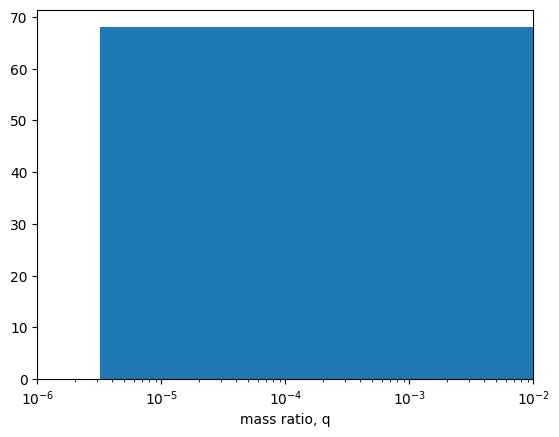

In [21]:
plt.hist(analyze_df['q'])
plt.xlabel('mass ratio, q')
plt.xscale('log')
plt.xlim([1e-6, 1e-2])
plt.show()

What did I even expect?

#### Actually useful analytics

How many events have LS, LO, and/or LX as the best model? 